# (ADA) Homework 1: Scoring the Language Model Olympics

---

By the end of this homework, we expect you to be able to:

- Load data and handle data using pandas;
- Navigate the documentation of Python packages by yourself;
- Filter and tidy up noisy real-world datasets;
- Aggregate your data in different (and hopefully helpful) ways;
- Create meaningful visualizations to analyze the data;
- Communicate your findings in a clear and concise manner

---

**Important Dates.**

- Homework release: Fri 04 Oct 2024
- Homework due: Sat 18 Oct 2024, 23:59
- Grade release: Mon 04 Nov 2024

**Some rules**

- You are allowed to use any built-in Python library that comes with Anaconda. If you want to use an external library, you may do so, but must justify your choice.
- Make sure you use the data folder provided in the repository in read-only mode. (Or alternatively, be sure you don’t change any of the files.)
- Be sure to provide a concise textual description of your thought process, the assumptions you made, the solution you implemented, and explanations for your answers. A notebook that only has code cells will not suffice. To avoid confusion: use short comments for longer code answers.
- For questions containing the /Discuss:/ prefix, answer not with code, but with a textual explanation (in markdown).
- Back up any hypotheses and claims with data, since this is an important aspect of the course.
- Please write all your comments in English, and use meaningful variable names in your code. Your repo should have a single notebook (plus the required data files) in the master/main branch. If there are multiple notebooks present, we will not grade anything.
- We will not run your notebook for you! Rather, we will grade it as is, which means that only the results contained in your evaluated code cells will be considered, and we will not see the results in unevaluated code cells. Thus, be sure to hand in a fully-run and evaluated notebook. In order to check whether everything looks as intended, you can check the rendered notebook on the GitHub website once you have pushed your solution there.
- In continuation to the previous point, interactive plots, such as those generated using the ‘plotly’ package, should be strictly avoided! Make sure to print results and/or dataframes that confirm you have properly addressed the task.

**A Note on using Language Models (LMs)**

If you try hard enough, you will likely get away with cheating. Fortunately, our job is not to police, but rather to educate! So, please consider the following:
- Presumably, you are taking this course to learn something! LMs are not always right ([they often fail in silly ways](https://community.openai.com/t/why-9-11-is-larger-than-9-9-incredible/869824/4)). This course should prepare you to detect when they are wrong!
- Some of the TAs on this course literally published many works on detecting machine-generated text.
---

## Context

Context
AI is booming! Newspapers, influencers, and your relatives all agree that AI is important. But while almost everyone agrees that AI is the future, much is unclear about what that future looks like…

Freshly graduated from the EPFL, you are hired by the Swiss government to advise on a large-scale “AI integration” initiative code-named **"NEUTRALITY"** (Navigating Efficient Upgrades Through Robust Artificial Learning Integration Techniques Yearly). Convinced by the stunning progress in language modeling, the government would like to battle the growing shortages in the education sector by using LMs. Your job description: investigate which LMs might be best suited!

You are given the results of three LMs on the [“Massive Multitask Language Understanding (MMLU)”](https://arxiv.org/abs/2009.03300) dataset to compare. This famous dataset consists of 57 subjects with multiple-choice questions, covering diverse subjects like mathematics, computer science, history, and law. Most providers of state-of-the-art LMs use this dataset to showcase the versatility of their latest models. Unfortunately, Horta-Ribeiro, the intern responsible for collecting the results, didn’t take EPFL’s famous ADA course. As a result, the collected datasets are slightly corrupted.

### A very brief primer on Language Models
Language models (LMs) are sophisticated statistical models designed to understand and generate human-like text. At their core, LMs are trained to predict the most likely continuation of a given input text. For example, given the input "The cat sat on the," an LM might predict "mat" as a likely continuation.
LMs are trained on vast text samples from various sources, including books, websites, and social media. This extensive training allows them to capture patterns and relationships in language, enabling them to generate coherent and contextually appropriate text across a wide range of topics and styles.

While LMs can produce text that appears to be written by intelligent humans, it's important to note that their capabilities can diverge from human intelligence in unexpected ways. They may sometimes generate factually incorrect information or struggle with complex reasoning tasks.

Two key concepts in understanding LMs are:
1. **Tokens**: LMs process text using "tokens" rather than individual characters. Tokens can be words, parts of words, or punctuation marks. For example, the sentence "I love AI!" might be tokenized as ["I", "love", "AI", "!"]. Tokenization is the first step in both training and using an LM.
2. **Context**: The input text provided to an LM is called the "context." This context informs the model's predictions or generations. A longer or more specific context often leads to more accurate and relevant outputs.

[See: Wikipedia entry on language models](https://en.wikipedia.org/wiki/Large_language_model)

###  Files for this assignment
This assignment is divided into three tasks, each of which should bring you a step closer to providing a recommendation toward project NEUTRALITY’s objectives:

- **Task 1**: Inspecting the results and getting your first model ranking
- **Task 2**: Inspecting the underlying data used to generate the results for possible biases
- **Task 3**: Learning about tokens and providing a final recommendation


```
📁 PROJECT_NEUTRALITY
│
├── 📄 analysis.ipynb (the file you're currently reading!)
├── 📄 requirements.txt (install into your environment)
│
├── 📁 task_1
├── 📁 task_2
└── 📁 task_2.5
```   
 

In [2]:
# please make sure you install the packages listed in the requirements.txt file in your environment!
# using pip
# pip install -r requirements.txt
#
# using Conda:
# conda create --name <env_name> --file requirements.txt
#
# some basic imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from scipy.stats import ttest_ind
from IPython.display import Markdown
import seaborn as sns
from collections import defaultdict

## Task 1 (18 points): What's in an average anyway?

The files needed to complete task 1 can be found in the folder "`data/task_1/`:
```
task_1/
│
├── mmlu_data/
│   └── test.csv
│
└── lm_scores/
    ├── lm_X.csv
    ├── lm_Y.csv
    └── lm_Z.csv
```

We will start by loading, (manually) inspecting, and cleaning the data. Although it doesn't seem "glamorous" (nor is it particularly fun...) - manually inspecting data is extremely important! In fact, it's one of the few things most AI and Data Science researchers agree on :). Next, we will take a first pass on ordering our Olympic podium between three LMs.

### 1.1 (1 pt)
 
Load the subfiles contained in the `mmlu_data` and `lm_scores` folders into separate dataframes:
- `df_test`
- `df_x`
- `df_y`
- `df_z`

for each, print their sizes.

In [3]:
# Defining data folder
DATA_SCORE_FOLDER = "task_1/lm_scores/"
DATA_TEST_FOLDER = "task_1/mmlu_data/"

# Since data is comma (',') separated, the read_csv method is used
df_x = pd.read_csv(DATA_SCORE_FOLDER + "lm_X.csv", delimiter=',', dtype={'result': str}, index_col='question_id')
df_y = pd.read_csv(DATA_SCORE_FOLDER + "lm_Y.csv", delimiter=',', dtype={'result': str}, index_col='question_id')
df_z = pd.read_csv(DATA_SCORE_FOLDER + "lm_Z.csv", delimiter=',', dtype={'result': str}, index_col='question_id')
df_test = pd.read_csv(DATA_TEST_FOLDER + "test.csv", delimiter=',', dtype={'result': str})

print("lm_X dataframe size: %d" % df_x.index.size)
print("lm_Y dataframe size: %d" % df_y.index.size)
print("lm_Z dataframe size: %d" % df_z.index.size)
print("mmlu_test dataframe size: %d" % df_test.index.size)

lm_X dataframe size: 13882
lm_Y dataframe size: 13978
lm_Z dataframe size: 13923
mmlu_test dataframe size: 14042


### 1.2 (4 pt)
Unfortunately, LMs don't always output the format we want. In the column `result`, the value should be one of A, B, C, or D. 

A. For each of the LM score dataframes, use a `value_counts()` operation and print the results. 

B. /Discuss:/ Inspect the results and describe the types of answer formats you see. Besides the "expected" case, you should be able to find at least four unexpected formats.

In [4]:
# A
# Making sure result column is a string datatype
print("|------- Dataframe lm_X count information --------|")
display(df_x['result'].value_counts(dropna=False)[:20])
print("|------- Dataframe lm_Y count information --------|")
display(df_y['result'].value_counts(dropna=False)[:20])

print("|------- Dataframe lm_Z count information --------|")
display(df_z['result'].value_counts(dropna=False)[:20])

|------- Dataframe lm_X count information --------|


result
A                                                                                                     2733
A                                                                                                     1657
B                                                                                                     1412
Answer: A                                                                                             1398
C                                                                                                     1134
D                                                                                                     1124
B                                                                                                      793
Answer: B                                                                                              760
C                                                                                                      622
Answer: D                     

|------- Dataframe lm_Y count information --------|


result
D                                                                                                                                                                                                                                                                     2894
Answer: D                                                                                                                                                                                                                                                             1718
C                                                                                                                                                                                                                                                                     1701
B                                                                                                                                                                                               

|------- Dataframe lm_Z count information --------|


result
D                                           2257
C                                           2191
B                                           2127
A                                           2060
Answer: D                                    777
Answer: C                                    748
Answer: B                                    712
Answer: A                                    687
NaN                                          345
C                                            316
D                                            314
B                                            285
A                                            279
Not Sure                                     125
None of the above                            119
Not wrong, Not wrong, so the answer is D      10
Wrong, Not wrong, so the answer is B           9
Wrong, Wrong, so the answer is A               9
Not wrong, Wrong, so the answer is C           8
all of the above, so the answer is D           2
Name: count, 

In [5]:
# B

The right dataformat expected for the 'result' column should be only the letter (like 'A', 'D'...)

However, some unexpected formats are present in the answers:
1. Presence of the keyword 'Answer: ' before the actual letter
2. Presence of an explanation of the though process before answering (sentence). Ex: 'The demand for labor is derived from the demand for the products produced by labor., so the answer is D'
3. Presence of the "Not Sure" expression
4. Presence of the "None of the above" expression
5. There are also empty answers, denoted as NaN
6. There is also something strange were capital letters 'A' or 'C' have been considered has 2 different values. After further inspection (using the index of the value_counts()), it turns out there is an extra space after the letter. For this particular case, the **str.strip()** method should be used.

### 1.3 (5 pt)
Oh oh... That doesn't look great. Simply dropping all invalid answers seems overly wasteful, yet fixing all of these looks like a mess! Instead, let's focus for now on fixing just those answers of length < 10 characters that require only a single `str.replace()` operation. 

For example, if the answer looks like `--A--`, we could fix this by using the following simple function:

```
def clean_answer(s, pattern='-'):
    return str(s).replace(pattern, '')

dirty_answer = '--A--'
clean_answer = clean_answer(dirty_answer)
```

A. Filter the three score dataframes to include only answers with less than 10 characters. Make a deep copy of the dataframes as you filter them.

B. Modify the `clean_answer()` example function to clean the answers in the filtered data frames using the `apply()` functionality. Finally, make sure **all remaining answers are one of `A, B, C, or D`.**

C. /Discuss:/ Compare the sizes of the original and filtered data frames. What do you see? Why might this be a problem?

In [6]:
# A
# Using the pandas apply function, check for elements with less than 10 characters
df_x_clean = df_x[df_x['result'].apply(lambda x: len(str(x)) < 10)].copy().dropna()
df_y_clean = df_y[df_y['result'].apply(lambda x: len(str(x)) < 10)].copy().dropna()
df_z_clean = df_z[df_z['result'].apply(lambda x: len(str(x)) < 10)].copy().dropna()

In [7]:
# B
def clean_answer(s, pattern='Answer: '):
    return str(s).strip().replace(pattern, '')

df_x_clean['result'] = df_x_clean['result'].apply(lambda x: clean_answer(x))
# Remove 'Not Sure' answer
df_x_clean = df_x_clean[df_x_clean['result'] != "Not Sure"]

df_y_clean['result'] = df_y_clean['result'].apply(lambda x: clean_answer(x))
df_y_clean = df_y_clean[df_y_clean['result'] != "Not Sure"]

df_z_clean['result'] = df_z_clean['result'].apply(lambda x: clean_answer(x))
df_z_clean = df_z_clean[df_z_clean['result'] != "Not Sure"]

print("|------- Dataframe lm_X_clean count information --------|")
display(df_x_clean['result'].value_counts(dropna=False))

print("|------- Dataframe lm_Y_clean count information --------|")
display(df_y_clean['result'].value_counts(dropna=False))

print("|------- Dataframe lm_Z_clean count information --------|")
display(df_z_clean['result'].value_counts(dropna=False))

|------- Dataframe lm_X_clean count information --------|


result
A    5788
B    2965
C    2350
D    2333
Name: count, dtype: int64

|------- Dataframe lm_Y_clean count information --------|


result
D    5757
C    3242
B    2519
A    2033
Name: count, dtype: int64

|------- Dataframe lm_Z_clean count information --------|


result
D    3348
C    3255
B    3124
A    3026
Name: count, dtype: int64

C. /Discuss:/

In [8]:
print("lm_X dataframe size: Original: %d | Filtered: %d | Diff: %d" % (df_x.index.size, df_x_clean.index.size, df_x.index.size-df_x_clean.index.size))
print("lm_Y dataframe size: Original: %d | Filtered: %d | Diff: %d" % (df_y.index.size, df_y_clean.index.size, df_y.index.size-df_y_clean.index.size))
print("lm_Z dataframe size: Original: %d | Filtered: %d | Diff: %d" % (df_z.index.size, df_z_clean.index.size, df_z.index.size-df_z_clean.index.size))

lm_X dataframe size: Original: 13882 | Filtered: 13436 | Diff: 446
lm_Y dataframe size: Original: 13978 | Filtered: 13551 | Diff: 427
lm_Z dataframe size: Original: 13923 | Filtered: 12753 | Diff: 1170


The original datasets already had different sizes, so that is not an issue. The problem is the removed data is different for each of the dataset, meaning that we might have remove some answers only in some datasets, while keeping a good answer in the other dataset. This leads to even more unusable data

### 1.4 (3 pt)

Now that our answer columns are nicely formatted, let's take a look at model performance:

A. Both the `MMLU` dataframes and the language model score data frames have the columns `question_id`. For each of the language model score data frames, use an inner join operation with the `df_test` dataframe on the `question_id` column.

B. Add a new column to each of the resulting dataframes called `correct`, that checks if the model's answer in `result` is the same as the expected answer in the column `answer`. Then, print the average score of each model.

In [9]:
# A
# Using a left inner join with the MMLU dataframe, adding _test to same name columns
df_x_perf = df_x_clean.join(df_test, on='question_id', how='left', rsuffix='_test')
df_y_perf = df_y_clean.join(df_test, on='question_id', how='left', rsuffix='_test')
df_z_perf = df_z_clean.join(df_test, on='question_id', how='left', rsuffix='_test')
df_x_perf.head(5)

,result,question,A,B,C,D,answer,subject,question_id
question_id,,,,,,,,,
0,B,Find the degree for the given field extension ...,0,4,2,6,B,abstract algebra,0
1,C,"Let p = (1, 2, 5, 4)(2, 3) in S_5 . Find the i...",8,2,24,120,C,abstract algebra,1
2,D,Find all zeros in the indicated finite field o...,0,1,"0,1","0,4",D,abstract algebra,2
3,B,Statement 1 | A factor group of a non-Abelian ...,"True, True","False, False","True, False","False, True",B,abstract algebra,3
4,B,Find the product of the given polynomials in t...,2x^2 + 5,6x^2 + 4x + 6,0,x^2 + 1,B,abstract algebra,4


In [10]:
# B
def print_performances(df: pd.DataFrame, model: str):
    """ Print the average of correct answers of a model

    Args:
        df (pd.DataFrame): Must contain the result and answer (ground truth) columns
        model (str): the model name
    """
    df['correct'] = (df.result == df.answer)

    print("Score of model {3}: {0}/{1} --> average: {2:.2f}%".format(df['correct'].sum(), df.index.size, 
                                                            df['correct'].sum()/df.index.size*100, model))

print_performances(df_x_perf, 'x')
print_performances(df_y_perf, 'y')
print_performances(df_z_perf, 'z')

Score of model x: 10312/13436 --> average: 76.75%
Score of model y: 10107/13551 --> average: 74.58%
Score of model z: 8459/12753 --> average: 66.33%


### 1.5 (5 pt)

Hmmm, something doesn't seem quite right. Let's investigate how "balanced" this dataset is:

A. For each of the 57 subjects in the MMLU, compare the number of questions answered by each model. Print the subjects for which there is a more than 10% difference.

B. Propose and implement a reasonable way to rebalance the results. (e.g., while throwing away 100% of the results perfectly rebalances the results, it is not reasonable).

C. Finally, print the updated accuracy on the rebalanced data.

**hint:**:
- (A) For a given subject, let model X and model Y have answered 181 and 200 questions respectively. You can consider this a 10% difference from the perspective of X since: (200 - 181) / 181 > 0.10

In [11]:
# A
THRESHOLD = 0.1
# Create a new dataframe containing the grouped subjects and the number of questions answered by each of the models
sub_cnt_x = df_x_perf.groupby('subject')['question_id'].count()
sub_cnt_x.name = 'count_x'
sub_cnt_y = df_y_perf.groupby('subject')['question_id'].count()
sub_cnt_y.name = 'count_y'
sub_cnt_z = df_z_perf.groupby('subject')['question_id'].count()
sub_cnt_z.name = 'count_z'
sub_cnt = pd.concat([sub_cnt_x, sub_cnt_y, sub_cnt_z], axis=1)
display(sub_cnt.head(5))
print("Total # of subjects: %d" % sub_cnt.index.size)

# Calculate difference w.r.t each of the models
sub_cnt['diff_xy'] = ((sub_cnt['count_y'] - sub_cnt['count_x']) / sub_cnt['count_x']).abs()
sub_cnt['diff_xz'] = ((sub_cnt['count_z'] - sub_cnt['count_x']) / sub_cnt['count_x']).abs()
sub_cnt['diff_yx'] = ((sub_cnt['count_x'] - sub_cnt['count_y']) / sub_cnt['count_y']).abs()
sub_cnt['diff_yz'] = ((sub_cnt['count_z'] - sub_cnt['count_y']) / sub_cnt['count_y']).abs()
sub_cnt['diff_zx'] = ((sub_cnt['count_x'] - sub_cnt['count_z']) / sub_cnt['count_z']).abs()
sub_cnt['diff_zy'] = ((sub_cnt['count_y'] - sub_cnt['count_z']) / sub_cnt['count_z']).abs()
display(sub_cnt[['diff_xy']].head(5))

# Checking any row which has at least (.any()) one value > 0.1 in one of the columns diff_*
# This is done using a filter on column names and a condition that returns a mask for the row indices
cols = [c for c in sub_cnt.columns if c.startswith('diff_')]
sub_diff = sub_cnt[(sub_cnt[cols] > THRESHOLD).any(axis=1)]
print("Subjects with a 10% more difference: ", end='\n  - ')
print('\n  - '.join(sub_diff.index))
print("(Total: %d)" % sub_diff.index.size)
sub_diff


,count_x,count_y,count_z
subject,,,
abstract algebra,95,97,95
anatomy,129,130,125
astronomy,144,148,137
business ethics,98,96,92
clinical knowledge,259,261,244


Total # of subjects: 57


,diff_xy
subject,
abstract algebra,0.021053
anatomy,0.007752
astronomy,0.027778
business ethics,0.020408
clinical knowledge,0.007722


Subjects with a 10% more difference: 
  - college chemistry
  - college computer science
  - computer security
  - formal logic
  - high school geography
  - logical fallacies
  - medical genetics
  - moral disputes
  - moral scenarios
(Total: 9)


,count_x,count_y,count_z,diff_xy,diff_xz,diff_yx,diff_yz,diff_zx,diff_zy
subject,,,,,,,,,
college chemistry,96,98,84,0.020833,0.125000,0.020408,0.142857,0.142857,0.166667
college computer science,97,98,84,0.010309,0.134021,0.010204,0.142857,0.154762,0.166667
computer security,95,98,87,0.031579,0.084211,0.030612,0.112245,0.091954,0.126437
formal logic,109,123,113,0.128440,0.036697,0.113821,0.081301,0.035398,0.088496
high school geography,195,193,176,0.010256,0.097436,0.010363,0.088083,0.107955,0.096591
logical fallacies,154,136,147,0.116883,0.045455,0.132353,0.080882,0.047619,0.074830
medical genetics,97,98,89,0.010309,0.082474,0.010204,0.091837,0.089888,0.101124
moral disputes,329,304,250,0.075988,0.240122,0.082237,0.177632,0.316000,0.216000
moral scenarios,737,865,774,0.173677,0.050204,0.147977,0.105202,0.047804,0.117571


**B.**

Proposed method for rebalancing dataaset: knowing that the datasets are unbalanced, one should remove the questions where only the model in excess (> 0.10 different) has answered in order to bring back the threshold under 10%.

Ex: model X > 0.1 difference with Y for subject 'computer security': removing 10 questions with 'question_id' only present in X for the subject will rebalance **correctly** the dataset.

In [12]:
# B
# df_x_perf[df_x_perf.subject.isin(sub_diff.index)].groupby(['subject', 'answer'])['question_id'].count().plot(kind='bar')
# Keep only rows where subjects are problematic
df_x_diff = df_x_perf[df_x_perf.subject.isin(sub_diff.index)]
df_y_diff = df_y_perf[df_y_perf.subject.isin(sub_diff.index)]
df_z_diff = df_z_perf[df_z_perf.subject.isin(sub_diff.index)]
# Perform an outer merge on indices to match questions answered by all models and fill NaN where models didn't answer the same questions
df_diff = df_x_diff.merge(df_y_diff, how='outer', left_index=True, right_index=True).merge(df_z_diff.add_suffix('_z'), how='outer', left_index=True, right_index=True)
# Keep only meaningfull columns (question_id_*)
df_diff = df_diff[[c for c in df_diff.columns if c.startswith(('question_id_', 'subject'))]]
# display(df_diff.head(5))

# Create dataframe indicating how much to remove for each model to be within the 10% margin
sub_diff.loc[:, 'min_value'] = sub_diff[[c for c in sub_diff.columns if c.startswith('count_')]].min(axis=1)
sub_diff.loc[:, 'min_model'] = sub_diff[[c for c in sub_diff.columns if c.startswith('count_')]].idxmin(axis=1).apply(lambda x: x[-1])
for s in ['x', 'y', 'z']:       
    sub_diff.loc[:,[f'adjust_{s}']] = np.ceil(sub_diff[f'count_{s}'] - sub_diff['min_value']*(1+THRESHOLD))
display(Markdown("### Rebalance strategy by downsampling models out of the 10% margin: "))
display(Markdown("Columns *adjust_* * with positive number indicates how many questions of the model needs to be removed." +
                 "\n\nThe *min_model* indicates which one is the lowest and thus should not be touched."))
display(sub_diff)

# Making a copy of the original dataframes because we're gonna drop some rows
df_x_balanced = df_x_perf.copy()
df_y_balanced = df_y_perf.copy()
df_z_balanced = df_z_perf.copy()
# display(df_diff.drop(['subject_x', 'subject_y', 'subject_z'], axis=1).sample(10))

def adjust_model(df: pd.DataFrame, s: str, k: int, target: str, source:str) -> list[int]:
    """ Performs adjustments given a number of values (k) to remove from target w.r.t 
    a source model

    Args:
        df (pd.DataFrame): a dataframe containing the questions id of the models (X,Y,Z) (must already me grouped by the subject)
        k (int): number of samples to remove from target
        target (str): model to downsample
        source (str): model with the lowest answered question for this subject

    Returns:
        list[int]: question id to be removed of the target df
    """
    # 0- Check that k is greater than 0
    if k < 0:
        return []
    # 1- Extrract rows of target with subject s
    df_1 = df[df[f'subject_{target}'] == s]
    # 2- filter out NaN questions on target
    df_2 = df_1[df_1[f'question_id_{target}'].notna()]
    # 3- select only rows where source is NaN
    df_3 = df_2[df_2[f'question_id_{source}'].isna()]
    # 4- return question ids to remove on target set
    return df_3.sample(k, replace=False).index

removed_total = []

for s, data in sub_diff.iterrows():
    models_to_check = ['x', 'y', 'z']
    min_model = data['min_model']
    models_to_check.remove(min_model)
    for m in models_to_check:
        k = int(data[f'adjust_{m}'])
        to_remove = adjust_model(df_diff, s, k, m, min_model)
        removed_total.extend(to_remove)
        eval(f'df_{m}_balanced').drop(to_remove, inplace=True)

# Printing the rebalanced subjects


C:\Users\alexa\AppData\Local\Temp\ipykernel_8092\1855823105.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_diff.loc[:, 'min_value'] = sub_diff[[c for c in sub_diff.columns if c.startswith('count_')]].min(axis=1)
C:\Users\alexa\AppData\Local\Temp\ipykernel_8092\1855823105.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_diff.loc[:, 'min_model'] = sub_diff[[c for c in sub_diff.columns if c.startswith('count_')]].idxmin(axis=1).apply(lambda x: x[-1])


### Rebalance strategy by downsampling models out of the 10% margin: 

Columns *adjust_* * with positive number indicates how many questions of the model needs to be removed.

The *min_model* indicates which one is the lowest and thus should not be touched.

,count_x,count_y,count_z,diff_xy,diff_xz,diff_yx,diff_yz,diff_zx,diff_zy,min_value,min_model,adjust_x,adjust_y,adjust_z
subject,,,,,,,,,,,,,,
college chemistry,96,98,84,0.020833,0.125000,0.020408,0.142857,0.142857,0.166667,84,z,4.0,6.0,-8.0
college computer science,97,98,84,0.010309,0.134021,0.010204,0.142857,0.154762,0.166667,84,z,5.0,6.0,-8.0
computer security,95,98,87,0.031579,0.084211,0.030612,0.112245,0.091954,0.126437,87,z,-0.0,3.0,-8.0
formal logic,109,123,113,0.128440,0.036697,0.113821,0.081301,0.035398,0.088496,109,x,-10.0,4.0,-6.0
high school geography,195,193,176,0.010256,0.097436,0.010363,0.088083,0.107955,0.096591,176,z,2.0,-0.0,-17.0
logical fallacies,154,136,147,0.116883,0.045455,0.132353,0.080882,0.047619,0.074830,136,y,5.0,-13.0,-2.0
medical genetics,97,98,89,0.010309,0.082474,0.010204,0.091837,0.089888,0.101124,89,z,-0.0,1.0,-8.0
moral disputes,329,304,250,0.075988,0.240122,0.082237,0.177632,0.316000,0.216000,250,z,54.0,29.0,-25.0
moral scenarios,737,865,774,0.173677,0.050204,0.147977,0.105202,0.047804,0.117571,737,x,-73.0,55.0,-36.0


In [13]:
# C
# Using the defined function for printing performances (1.4)
print_performances(df_x_balanced, 'x')
print_performances(df_y_balanced, 'y')
print_performances(df_z_balanced, 'z')

Score of model x: 10262/13366 --> average: 76.78%
Score of model y: 10032/13447 --> average: 74.60%
Score of model z: 8459/12753 --> average: 66.33%


## Task 2 (26 points): What do you mean A > D > B > C...?

Nice work! Having successfully inspected, cleaned, and rebalanced the provided data, you head over to director of the government's NEUTRALITY project. Ms. Sakota is happy with your work so far, but worried that the sloppy intern might have done more undetected damage. To be sure, she orders a new set of evaluations of all models on both MMLU and another dataset.

After cleaning up and rebalancing, you are left with the concatenated score files in the second folder `task_2`:
```
task_2/
│
└── lm_scores_mmlu.csv
│
└── lm_scores_other.csv
```

Each has a new column called `model_name`, which is one of `X, Y` or `Z`.



_NOTE: **only** use data from `task_2` and `task_2_5` for this assignment! The values in `lm_scores_mmlu.csv` will NOT be the same as the dataframes you finished in task 1. This is due to "randomness" or "temperature" in language model inference. This can slightly shift around generative results. (Conveniently: it also ensures any mistakes made in Task 1 don't propogate further ;) )_

In [14]:
# PROVIDED CODE
df_mmlu = pd.read_csv('task_2/lm_scores_mmlu.csv')
df_other = pd.read_csv('task_2/lm_scores_other.csv')

### 2.1 (4 pt)

Let's explore the new results:

A. Compute the mean accuracy and standard errors of each model on both datasets and print the results.

B. Then, show your results in a bar plot using standard errors with a 95% confidence interval around the mean. Make sure the plot is easy to read and well annotated.

C. /Discuss:/ the plot you created: (i) can you say that one of the models is the best? (ii) is there anything that seems odd?

In [15]:
# A

In [16]:
# B

C. /Discuss:/

### 2.2 (5 pt)

Ms. Sakota has assured you that both datasets contain questions of similar difficulty, so, what could be going on here?

A. What is the distribution of correct answers (A, B, C, D) for each dataset? Create a bar chart to visualize this.

B. Perform a chi-square test at $\alpha = 0.05$, of independence to determine if there's a significant difference in the distribution of correct answers between the two datasets. What do you conclude?

**hints**:
- for (A), keep in mind that df_mmlu and df_other contain the results of all models, i.e., the `question_id` column is duplicated.
- for (A), take care to clearly annotate the bar chart, e.g., title, y-label, legend.
- for (B), clearly state the null hypothesis and alternative hypothesis
- use the `chi2_contingency` function from `scipy.stats`
- format your results from answer (A) as a 2D array

In [17]:
# A

In [18]:
# B

### 2.3 (7 pt)

Let's dive in deeper:

A. What is language model X's mean accuracy conditioned on the four answer options for each dataset?

B. Compare LM X's performance when the correct answer is "A" between the two datasets. Use a T-test with CI = 0.95. What do you conclude?

C. Compare LM X's performance when the correct answer is "A" vs. "C or D" for each dataset. Use a T-test with CI = 0.95. What do you conclude?

In [19]:
# A

In [20]:
# B

In [21]:
# C

### 2.4 (2 pt)

What an intriguing finding! 

A. Print the mean accuracies conditioned on the correct answer for all LMs for each dataset.

B. /Discuss:/ What do you observe?

In [22]:
# A

B. /Discuss:/

### 2.5 (2 pt)

Concerned with your findings so far, you quickly consult with Ms. Sakota. After thinking it over, Ms. Sakota concludes that more tests are needed. She orders a second round of MMLU results. However, the clever Ms. Sakota thinks of the following twist: while keeping questions fixed, she randomly permutes the position of the correct answer. The new results can be found in the folder `data/task_2_5/`:
```
task_2_5/
│
└── lm_scores_mmlu_shuffle.csv
```

/Discuss:/ Why would Ms. Sakota do this?

/Discuss:/

### 2.6 (4 pt)

Increasingly sceptical of the language models' performance, you read up on proper testing practices. You stumble upon the concept of [test-rested stability](https://en.wikipedia.org/wiki/Repeatability), which roughtly states that:

"_Measurements taken by a single person or instrument on the same item, under the same conditions, and in a short period of time, should have the same results._"

In our case, we would assume an LM would have the same performance on a given question regardless of the correct answer position. One way of testing this is by using the following metric:

$$\text{test-retest metric} = \frac{1}{N}\sum_{i=1}^N \frac{1}{M}\sum_{j=1}^M c^i_0 c_j^i,$$

where $c^i_0 \in \{0, 1\}$ indicates whether the model answers the $i^{\text{th}}$ question correctly (1 if correct, 0 if incorrect). $c_j^i$ indicates whether the model answers the $i^{\text{th}}$ question correctly in the $j^{\text{th}}$ shuffled version of the answer label content. Finally, $M$ is the total number of shuffles and $N$ is the dataset size.

Task: compute the test-retest metric for each language model using the original `lm_scores_mmlu.csv` file and the new `lm_scores_mmlu_shuffle.csv` file. Using a bar plot, visualize your results by comparing the accuracy of the original `lm_scores_mmlu.csv` and the test-retest scores.

**hints**
- what is $M$ in our case?

(bonus: no points, but so much sweet, sweet knowledge - check out [the following article](https://arxiv.org/pdf/2406.19470v1))

### 2.7 (2 pt)

A. Using the unshuffled data: For each LM, print the distribution of the answers they give as well as the accuracy conditioned on the answer they give.

B. /Discuss:/ Describe what you observe

[bonus: not scored, but again _that sweet, sweet knowledge_] Could you think of a plausible explanation?

In [23]:
# A

B. /Discuss:/

## Task 3 (16 points): What do Questions and Answers look like for a Language Model?

While you feel pretty good about the tests you conducted so far, something still bothers you: what if the language models don't see the data like you do? Suddenly, you receive a phone call from a wise AI sage in the West, _Westoda_:

```
"Hmm, correct you are, young padawan, to question how the world is seen by large language models! Simple 'text' it is not, hmm? No, no, no! Characters and words, the way of puny humans, this is not, heh heh heh.

'Tokens', they use, yes! Mysterious and powerful, these tokens are. Expand our vocabulary, they do, beyond the simple 'a to Z'. Chunky blocks of text, they become, yes! 'Hello world', a simple phrase it may seem. But to a language model, '[24912, 2375]' it might appear, yes! Confusing, it is, hmm?

Wise, it would be, to explore these MMLU data points through the eyes of a language model, you think? Yes, yes! Much to learn, there is. The ways of the tokens, understand you must, if truly comprehend the great LMs, you wish to.
Meditate on this, you should. The force of natural language processing, strong it is. But patience, you must have, my young padawan. For only through great study and contemplation, will the mysteries of the tokens reveal themselves to you, they will. Yes, hmmm!"
```

Admittingly, Westoda at times speaks in riddles… However, he was explaining a crucial aspect of modern LMs called [Tokenization](https://learn.microsoft.com/en-us/dotnet/ai/conceptual/understanding-tokens):


“Tokens are words, character sets, or combinations of words and punctuation that are used by [language models (LMs)] to decompose text into. Tokenization is the first step in training”

Instead of characters, LMs process natural language using “tokens”. While this is useful for a number of reasons, it does at times introduce some “unintuitive” behavior…

In [24]:
# PROVIDED CODE

try:
    import tiktoken
except Exception as e:
    print('installing tiktoken package')
    
    !pip install tiktoken
    
    import tiktoken

def tokenize_text(s):
    enc = tiktoken.encoding_for_model('gpt-4o')
    tokens = enc.encode(str(s))
    return tokens

example_string = 'hello world'
print(f'humans see: "{example_string}" --> language models see: {tokenize_text(example_string)}')

humans see: "hello world" --> language models see: [24912, 2375]


### 3.1 (5 pt)

Use the provided code in the cell above to "see the world through the eyes of a language model":

A. Tokenize the questions of the original MMLU data provided in task 1: `task_1/mmlu_data/test.csv` and plot the token distribution (the frequency of each token).

B. Same as (A), but now for the answers in columns (columns "A", "B", "C", and "D").

C. Isolate the tokens for the strings "A", "B", "C", and "D", then, for their occurances in both questions and answers, print their relative distribution to each other.

**hint**
- There are a _lot_ of tokens, consider using a cutoff point and log scale
- For (c), they should sum to 1

Total number of tokens from all questions: 802276
Facts about the distribution: 


count    773296.000000
mean       9146.779888
std       17525.787385
min           0.000000
25%         316.000000
50%        1218.000000
75%        8773.000000
max       99985.000000
dtype: float64

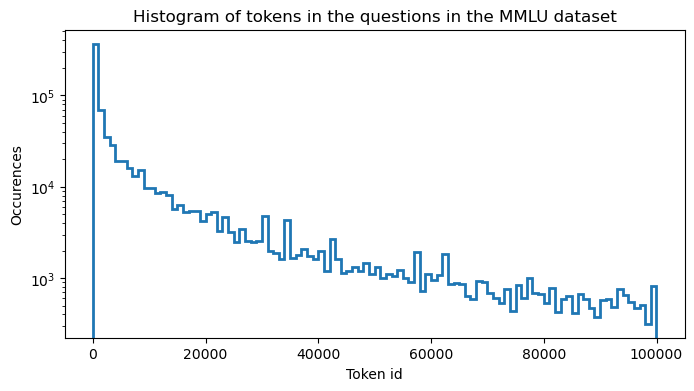

In [31]:
# A
DATA_TEST_FOLDER = "task_1/mmlu_data/"
df_mmlu = pd.read_csv(DATA_TEST_FOLDER + "test.csv", delimiter=',', dtype={'result': str})
# Tokenize every row of the question column (extending an array)
tokens_questions = np.array([], dtype=np.int32)
for q in df_mmlu['question']:
    tokens_questions = np.concatenate((tokens_questions, tokenize_text(q)))

# Converting into pd series to have access to the special plotting functions
tokens_questions = pd.Series(tokens_questions)
print(f"Total number of tokens from all questions: {tokens_questions.size}")

# Add a cutoff point
CUTOFF = 100_000
tokens_questions = tokens_questions[tokens_questions < CUTOFF]

plt.figure(figsize=(8,4))
plt.hist(tokens_questions, bins=100, log=True, histtype='step', linewidth=2)
plt.xlabel("Token id")
plt.ylabel("Occurences")
plt.title("Histogram of tokens in the questions in the MMLU dataset")
print("Facts about the distribution: ")
tokens_questions.describe()

Facts about the distribution: 


count    461503.000000
mean      11038.743332
std       19513.249028
min           0.000000
25%         326.000000
50%        1716.000000
75%       11570.000000
max       99993.000000
dtype: float64

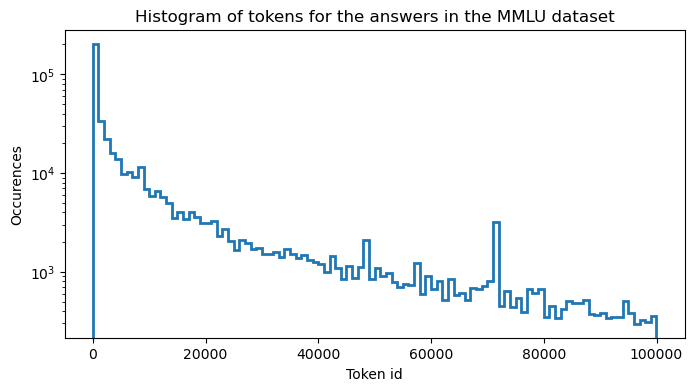

In [32]:
# B
tokens_answers = np.array([], dtype=np.int32)
for a in df_mmlu[['A', 'B', 'C', 'D']].astype(str).values:
    tokens_answers = np.concatenate((tokens_answers, tokenize_text(' '.join(a))))

tokens_answers = pd.Series(tokens_answers)

# Add a cutoff point
CUTOFF = 100_000
tokens_answers = tokens_answers[tokens_answers < CUTOFF]

plt.figure(figsize=(8,4))
plt.hist(tokens_answers, bins=100, log=True, histtype='step', linewidth=2)
plt.xlabel("Token id")
plt.ylabel("Occurences")
plt.title("Histogram of tokens for the answers in the MMLU dataset")
print("Facts about the distribution: ")
tokens_answers.describe()

,token,count,origin
0,35,0.020859,question
1,34,0.041718,question
2,33,0.031902,question
3,32,0.905521,question
0,35,0.089744,answer
1,34,0.259615,answer
2,33,0.113782,answer
3,32,0.536859,answer


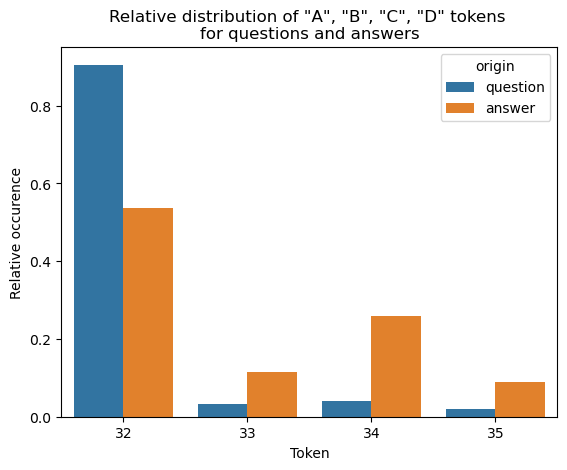

In [33]:
# C
# Locating the rows where token is one of the 'A', 'B', 'C', 'D' and calculating the relative count
df_questions = pd.DataFrame(tokens_questions.value_counts().loc[[35,34,33,32]]).reset_index()
df_questions.rename(columns={'index': 'token'}, inplace=True)
df_questions['count'] = df_questions['count'] / df_questions['count'].sum()
df_questions['origin'] = 'question'

# Same for answers
df_answers = pd.DataFrame(tokens_answers.value_counts().loc[[35,34,33,32]]).reset_index()
df_answers.rename(columns={'index': 'token'}, inplace=True)
df_answers['count'] = df_answers['count'] / df_answers['count'].sum()
df_answers['origin'] = 'answer'
# Merging the 2 datasets, making sure to have an 'origin' column for the seaborn barplot
df_relative = pd.concat([df_questions, df_answers], axis=0)

# OUTPUT #
display(df_relative)
sns.barplot(x='token', y='count', hue='origin', data=df_relative)
plt.ylabel('Relative occurence')
plt.xlabel('Token')
plt.title('Relative distribution of "A", "B", "C", "D" tokens \nfor questions and answers')
plt.show()

### 3.2 (3 pt)

What if the number of "A", "B", "C", and "D" tokens in the question and answer pairs could influence a language model's decisions?

A. For each combined question-answers pair, compute: 
1. the number of "A", "B", "C", and "D" tokens; and
2. the total number of tokens.
3. then, group by the "correct" answer and compute the mean frequency of A, B, C, and D tokens and the total number of tokens. 
4. finally, print your results

B. /Discuss:/ What do you think of the hypothesis that the frequency of A, B, C, and D tokens could influence answers?


In [66]:
# A
df_mmlu_pairs = df_mmlu.copy()
# Creating question-answer pairs (concatenating strings)
df_mmlu_pairs['pairs'] = df_mmlu_pairs[['question', 'A', 'B', 'C', 'D']].astype(str).agg(' '.join, axis=1)

# Tokenize the pairs and calculate the different lenght of arrays (using list functions)
df_mmlu_pairs['token_pairs'] = df_mmlu_pairs['pairs'].apply(tokenize_text)
df_mmlu_pairs['tokens_total'] = df_mmlu_pairs['token_pairs'].apply(lambda x: len(x))
tokens = [tokenize_text(s)[0] for s in ["A", "B", "C", "D"]]
df_mmlu_pairs['tokens_A'] = df_mmlu_pairs['token_pairs'].apply(lambda x: x.count(tokens[0]))
df_mmlu_pairs['tokens_B'] = df_mmlu_pairs['token_pairs'].apply(lambda x: x.count(tokens[1]))
df_mmlu_pairs['tokens_C'] = df_mmlu_pairs['token_pairs'].apply(lambda x: x.count(tokens[2]))
df_mmlu_pairs['tokens_D'] = df_mmlu_pairs['token_pairs'].apply(lambda x: x.count(tokens[3]))
# df_mmlu_pairs[['tokens_total', 'tokens_A', 'tokens_B', 'tokens_C', 'tokens_D']].sample(10)

# Compute the mean of "correct" answers by grouping the answer column
df_mmlu_pairs_feq = df_mmlu_pairs.groupby('answer')[['tokens_A', 'tokens_B', 'tokens_C', 'tokens_D', 'tokens_total']].mean().add_suffix('_mean')

# OUTPUT #
df_mmlu_pairs_feq

,tokens_A_mean,tokens_B_mean,tokens_C_mean,tokens_D_mean,tokens_total_mean
answer,,,,,
A,0.157045,0.007138,0.012725,0.004345,92.819677
B,0.167244,0.010976,0.010976,0.004910,88.619295
C,0.158012,0.009771,0.016192,0.005304,92.449470
D,0.165784,0.005032,0.017214,0.005032,91.853814


B. /Discuss:/

### 3.3 (4 pt)

Three of the most important considerations when deciding between language models are:

Quality
Costs
Speed

So far, much of your analysis has focused on quality. However, the government has indicated that they are quite concerned about both the total costs and speed as well. Specifically, it has been brought to their attention that a new `turbo` model has been launched! 

This model is both cheaper and faster than the models you evaluated so far. However, there is a catch: the context length* is much smaller than that of the other LMS. Namely, it can only process **300** tokens during inference. Meanwhile, the other models can process up to 100K tokens! 

*_The “context length” refers to the number of tokens that can be given to an LM as input._

A. Are there subjects where using the cheaper model might be problematic? I.e., where part of the question and answer(s) might not fit completely in the context?

B. /Discuss:/ Can you think of a strategy that would balance the needs of the government?

**hint**:
- An LM needs to have both the question and the different answer options in its context

In [65]:
# A
# Reusing the dataframe of the previous question with already computed total tokens for pairs
# To quickly identify subjects with context >300, find the max context length within every subject and filter by subjects > 300
subjects_over = df_mmlu_pairs.groupby('subject')['tokens_total'].max()
subjects_over = pd.DataFrame(subjects_over[subjects_over > 300])
# For more stats (for discussion), counting the number of context higher than 300 within all subjects
subjects_over['count'] = df_mmlu_pairs[df_mmlu_pairs['tokens_total'] > 300].groupby('subject')['question'].count()
subjects_over['proportions'] = (subjects_over['count'] / subjects_over['tokens_total'] * 100).round(2)

# OUTPUT #
print("Subjects with question-answer pairs having more than 300 tokens: ")
display(subjects_over.sort_values(by='count', ascending=False).rename(columns=
    {'tokens_total': 'Total tokens', 
     'count': '# of oversize', 
     'proportions': '%'}))
print(f'Total number of subjects: {subjects_over.index.size} out of {df_mmlu['subject'].unique().size}')

Subjects with question-answer pairs having more than 300 tokens: 


,Total tokens,# of oversize,%
subject,,,
professional law,712,312,43.82
high school world history,721,122,16.92
high school european history,630,93,14.76
high school us history,504,85,16.87
professional medicine,376,14,3.72
college medicine,944,5,0.53
security studies,391,3,0.77
high school computer science,396,1,0.25
high school statistics,337,1,0.30


Total number of subjects: 10 out of 57


B. /Dicsuss:/

- They could use the lighter model for most of the subjects and keep the heavier one for the only four subjects where the % of oversized context is > 10
- 

### 3.4 (4 pt)

/Discuss:/ The time has come to give your final recommendation on the use of LMs in education to the government! Taking into account everything you analyzed in all the preceding tasks (1, 2, and 3), please write a short recommendation consisting of 4 bullet points discussing your concerns.

**hint**
- Try to use the MECE framework: _Mutually Exclusive Collectively Exhaustive_

/Discuss:/
1. 

2. 

3. 

4. 